## Loading Main Packages

In [4]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

import wave_aux as wa

un_var= {"Hs": " [m]","Tp": " [s]","Dirp": " [°]","Dirm": " [°]"}

### Loading Data File

In [5]:
fin='./Point_out_000260.dat'
pdW=wa.readWave(1,'../data/'+fin,0)
pdW

,Hs,T02,T01,Tm10,Tp,Dirm,Dirp,Spr,Hs0,Tp0,...,Dirp2,gam2,spr2,Hs3,Tp3,Dirp3,gam3,spr3,uw,vw
YYYY-MM-DD hh:mm:ss,,,,,,,,,,,,,,,,,,,,,
1979-01-01 00:00:00,0.000,1.52,1.52,1.52,1.96,270.0,227.3,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.51,5.12
1979-01-01 01:00:00,0.232,1.47,1.58,1.74,1.96,228.2,227.3,26.1,0.232,1.96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.30,6.07
1979-01-01 02:00:00,0.706,2.23,2.41,2.65,3.02,229.1,226.5,31.7,0.706,3.02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.40,8.38
1979-01-01 03:00:00,1.151,3.03,3.30,3.63,4.18,222.7,217.8,30.1,1.151,4.18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.65,8.66
1979-01-01 04:00:00,1.472,3.66,4.00,4.42,5.08,219.4,216.1,27.6,1.472,5.08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.12,7.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-30 20:00:00,1.140,4.57,5.20,6.09,7.52,205.5,221.8,37.8,NaN,NaN,...,152.6,2.24,0.5,0.257,4.43,280.2,2.20,0.4,-2.42,-2.08
2025-01-30 21:00:00,1.145,4.54,5.17,6.08,7.52,207.2,221.6,38.0,NaN,NaN,...,153.4,2.19,0.5,0.305,4.40,280.6,2.12,0.4,-2.58,-2.36
2025-01-30 22:00:00,1.154,4.46,5.10,6.02,7.51,209.0,221.2,39.2,NaN,NaN,...,159.3,2.27,0.4,0.356,4.37,281.0,2.06,0.5,-1.61,-0.75


## **Annual Maxima**

In [6]:
# Calling function for Annual Maxima
df=wa.am(pdW,'Hs')

# Sorting in descending order depending on Hs values
dfs = df.sort_values(by='Hs', ascending=True)

# Developing Plottin Position
n=len(dfs)
dfs['rank'] = dfs['Hs'].rank(method='first')
dfs['r_W']=dfs['rank']/(n+1)           # Weibull (1939)
dfs['r_G']=(dfs['rank']-0.44)/(n+0.12) # Gringorten (1963)
dfs['r_H']=(dfs['rank']-0.5)/n         # Hazen (1914)
dfs['r_B']=(dfs['rank']-0.31)/(n+0.38) # Beard (1943)
dfs

,Hs,T02,T01,Tm10,Tp,Dirm,Dirp,Spr,Hs0,Tp0,...,Dirp3,gam3,spr3,uw,vw,rank,r_W,r_G,r_H,r_B
YYYY-MM-DD hh:mm:ss,,,,,,,,,,,,,,,,,,,,,
2009-01-24 23:00:00,3.153,6.22,7.23,8.90,12.19,242.2,214.7,57.0,1.862,5.76,...,NaN,NaN,NaN,3.48,-12.80,1.0,0.020833,0.011885,0.010638,0.014563
1980-10-18 05:00:00,3.462,6.72,7.63,8.81,10.25,195.4,197.2,25.7,3.212,10.49,...,NaN,NaN,NaN,5.82,7.20,2.0,0.041667,0.033107,0.031915,0.035669
2022-04-07 23:00:00,3.473,7.02,7.67,8.46,9.48,214.4,217.6,20.6,NaN,NaN,...,NaN,NaN,NaN,3.37,1.47,3.0,0.062500,0.054329,0.053191,0.056775
1983-11-27 13:00:00,3.506,5.75,6.28,6.97,7.95,205.7,206.5,28.1,3.506,7.95,...,NaN,NaN,NaN,10.56,13.68,4.0,0.083333,0.075552,0.074468,0.077881
1996-11-20 16:00:00,3.554,7.19,8.08,9.13,10.39,213.1,213.3,20.1,NaN,NaN,...,NaN,NaN,NaN,6.55,3.26,5.0,0.104167,0.096774,0.095745,0.098987
1984-09-23 16:00:00,3.559,5.65,6.17,6.83,7.86,217.4,219.8,27.2,3.559,7.86,...,NaN,NaN,NaN,11.88,13.49,6.0,0.125000,0.117997,0.117021,0.120093
1991-10-18 17:00:00,3.600,6.02,6.62,7.38,8.48,221.2,220.9,24.7,3.600,8.48,...,NaN,NaN,NaN,13.44,6.87,7.0,0.145833,0.139219,0.138298,0.141199
2002-02-20 23:00:00,3.600,7.36,8.07,8.93,10.13,214.1,215.3,20.5,NaN,NaN,...,NaN,NaN,NaN,3.61,1.67,8.0,0.166667,0.160441,0.159574,0.162305
1987-04-04 08:00:00,3.605,5.92,6.47,7.17,8.30,145.3,150.5,30.5,3.548,8.32,...,NaN,NaN,NaN,-10.49,11.22,9.0,0.187500,0.181664,0.180851,0.183411


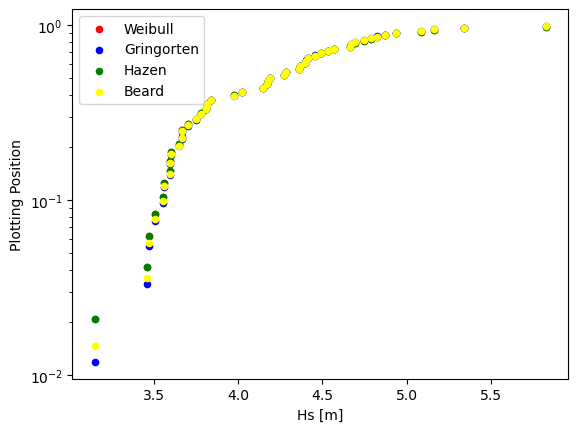

In [7]:
# Plotting Positions
fig, ax = plt.subplots()
dfs.plot.scatter(x='Hs', y='r_W', color='red', label='Weibull', ax=ax, logy=True)
dfs.plot.scatter(x='Hs', y='r_G', color='blue', label='Gringorten', ax=ax, logy=True)
dfs.plot.scatter(x='Hs', y='r_W', color='green', label='Hazen', ax=ax, logy=True)
dfs.plot.scatter(x='Hs', y='r_B', color='yellow', label='Beard', ax=ax, logy=True)
plt.xlabel('Hs [m]')
plt.ylabel('Plotting Position')
plt.legend()

In [8]:
# Fitting GEV to data
var='Hs'
pp='r_W'
c, loc, scale = stats.genextreme.fit(dfs[var])
print(f"GEV parameters: c={c:.3f}, loc={loc:.3f}, scale={scale:.3f}")

GEV parameters: c=0.109, loc=3.969, scale=0.504


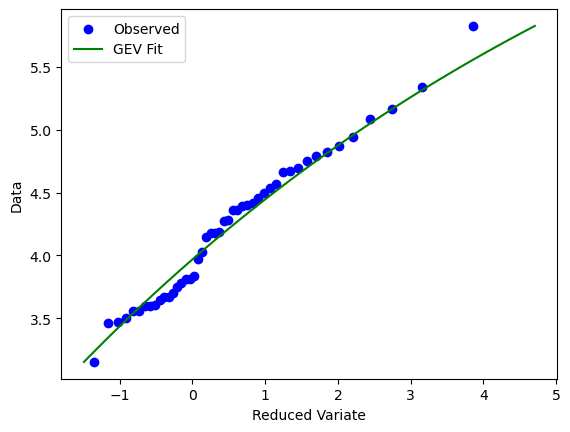

In [9]:
# CDF for plotting
#x_fit = np.linspace(2,10, 100)
x_fit = np.linspace(dfs[var].min(),dfs[var].max(), 100)
y_fit = stats.genextreme.cdf(x_fit, c, loc=loc, scale=scale)
y_fit_reduced = -np.log(-np.log(y_fit))
y = -np.log(-np.log(dfs[pp]))

plt.scatter(y, dfs['Hs'], color='blue', label='Observed')
plt.plot(y_fit_reduced, x_fit, color='green', label='GEV Fit')
plt.xlabel('Reduced Variate')
plt.ylabel('Data')
plt.legend()
plt.show()

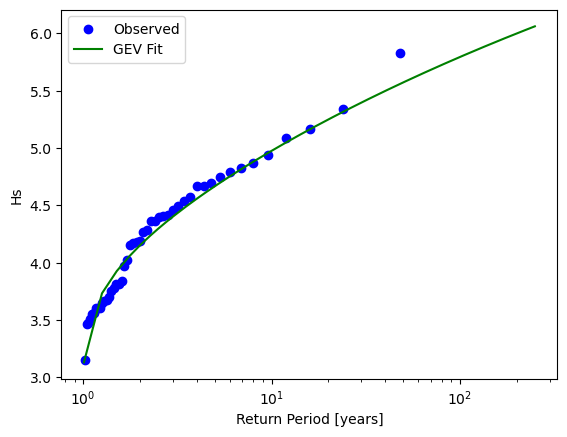

In [10]:
# Return periods for plotting (log scale often used)
T_fit=np.linspace(1.01, 250, 1000)
T=1/(1-dfs[pp])

# Convert T to non-exceedance probability
P_fit = 1 - 1/T_fit
data_fit = stats.genextreme.ppf(P_fit, c, loc=loc, scale=scale)

plt.scatter(T, dfs[var], color='blue', label='Observed')
plt.plot(T_fit, data_fit, color='green', label='GEV Fit')
plt.xscale('log')  # commonly log scale for return period
plt.xlabel('Return Period [years]')
plt.ylabel(var)
plt.legend()
plt.show()

In [11]:
rL, ci_L, ci_U, param=wa.gev_return_ci(dfs[var], T_fit, method="bootstrap", alpha=0.05, n_boot=1000)

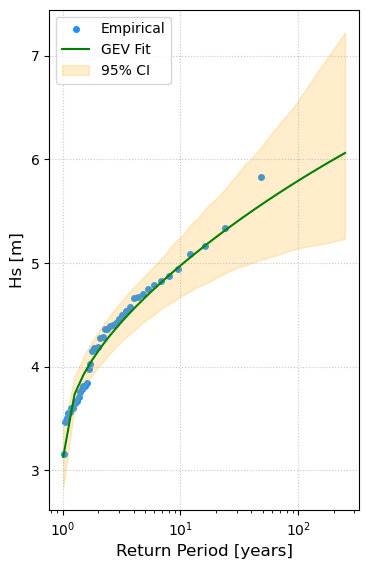

In [12]:
plt.figure(figsize=(4, 6.5))
plt.scatter(T, dfs[var], color='dodgerblue', label='Empirical', s=16)
plt.plot(T_fit, rL, color='green', label='GEV Fit')
plt.fill_between(T_fit, ci_L, ci_U,
                 color='orange', alpha=0.2,
                 label='95% CI')
plt.xscale('log')
plt.xlabel('Return Period [years]', fontsize=12)
plt.ylabel(var+un_var[var], fontsize=12)
plt.legend()
plt.grid(True, alpha=0.7, linestyle='dotted')
plt.show()

In [13]:
# Example: Calculate return period for a given Hs value
c=param[0]
loc=param[1]
scale=param[2]
hs_value = 6.0  # Change this to your desired value
T_calculated = wa.value_to_return_period(hs_value, c, loc, scale)
print(f"For {var} = {hs_value:.2f} m, the return period is {T_calculated:.2f} years")

For Hs = 6.00 m, the return period is 201.66 years


(np.float64(0.10854608218364173),
 np.float64(3.9685362171084497),
 np.float64(0.5037731264678691))